# Multistage & Mission Architecture

Demonstrates the multistage/mission architecture as it is built up commit by commit (see `mission_multistage_design.md`). Each section below corresponds to one landed commit. This is the last item on the original roadmap - see "Not built yet" at the bottom for what's deliberately still out of scope.

**Landed so far:**
1. `Stage` — wraps a single-stage `Rocket`
2. `Deployable` — a carried payload released mid-flight
3. `MultiStageRocket` — composes a stage + its deployables into one flight-ready `Rocket`
4. `MultiStageRocket.flight_rocket` for more than one active stage (a booster with an inert sustainer riding on top)
5. `Mission` — orchestrates one `Flight` per vehicle configuration: the single-stage degenerate case, a full two-stage mission (deterministic burnout+delay separation, state handoff, ignition timing), and a deployable ejecting at apogee
6. `MultiStageRocket.draw()`, `Mission.trajectories_3d()` / `Mission.positions()` — visualizing the stacked vehicle and comparing trajectories across bodies, both by reusing RocketPy's existing plotting (`Rocket.plots`, `CompareFlights`) rather than building anything new

In [1]:
from rocketpy import NoseCone, Rocket, SolidMotor
from rocketpy.rocket.multistage import Deployable, MultiStageRocket, Stage

## Building a base rocket

`Stage` and `MultiStageRocket` wrap ordinary `Rocket` objects — nothing new is needed to build one. This is the same Calisto rocket used throughout the RocketPy docs.

In [2]:
Pro75M1670 = SolidMotor(
    thrust_source="../../data/motors/cesaroni/Cesaroni_M1670.eng",
    dry_mass=1.815,
    dry_inertia=(0.125, 0.125, 0.002),
    nozzle_radius=33 / 1000,
    grain_number=5,
    grain_density=1815,
    grain_outer_radius=33 / 1000,
    grain_initial_inner_radius=15 / 1000,
    grain_initial_height=120 / 1000,
    grain_separation=5 / 1000,
    grains_center_of_mass_position=0.397,
    center_of_dry_mass_position=0.317,
    nozzle_position=0,
    burn_time=3.9,
    throat_radius=11 / 1000,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

calisto = Rocket(
    radius=127 / 2000,
    mass=14.426,
    inertia=(6.321, 6.321, 0.034),
    power_off_drag="../../data/rockets/calisto/powerOffDragCurve.csv",
    power_on_drag="../../data/rockets/calisto/powerOnDragCurve.csv",
    center_of_mass_without_motor=0,
    coordinate_system_orientation="tail_to_nose",
)
calisto.add_motor(Pro75M1670, position=-1.255)

print(f"calisto.dry_mass = {calisto.dry_mass:.4f} kg")
print(f"calisto.motor.burn_out_time = {calisto.motor.burn_out_time} s")

calisto.dry_mass = 16.2410 kg
calisto.motor.burn_out_time = 3.9 s


## `Stage`: wrapping a rocket as one stage of a vehicle

For now `Stage` is a thin wrapper: `dry_mass` and `burn_out_time` just forward to the wrapped `Rocket`'s own already-computed attributes. It becomes meaningful once `MultiStageRocket` composes several stages together (a later commit).

In [3]:
booster = Stage(name="booster", rocket=calisto)

print(f"booster.dry_mass = {booster.dry_mass:.4f} kg")
print(f"booster.burn_out_time = {booster.burn_out_time} s")

assert booster.dry_mass == calisto.dry_mass
assert booster.burn_out_time == calisto.motor.burn_out_time

booster.dry_mass = 16.2410 kg
booster.burn_out_time = 3.9 s


## `Deployable`: a payload carried and ejected mid-flight

A `Deployable` contributes only mass and inertia while attached. Its free-flight aerodynamics come from either a fully built `free_rocket`, or surfaces added one at a time with `add_surface()` — the two are mutually exclusive, and `add_surface()` requires `radius` to be set.

In [4]:
payload = Deployable(
    name="payload",
    mass=4.5,
    inertia=(0.1, 0.1, 0.001),
    position=1.10,
    radius=0.05,
)

print(f"payload.mass = {payload.mass} kg")
print(f"payload.position = {payload.position} m")
print(f"payload.surfaces (before add_surface) = {payload.surfaces}")

payload.mass = 4.5 kg
payload.position = 1.1 m
payload.surfaces (before add_surface) = []


In [5]:
# add_surface requires radius to be set
no_radius_payload = Deployable(
    name="no_radius_payload", mass=1.0, inertia=(0, 0, 0), position=0.5
)
nose = NoseCone(length=0.2, kind="vonKarman", base_radius=0.05, rocket_radius=0.05)
try:
    no_radius_payload.add_surface(nose, position=0.1)
except ValueError as error:
    print(f"Raised as expected: {error}")

Raised as expected: add_surface requires radius to be set on the deployable.


In [6]:
# add_surface and free_rocket are mutually exclusive
payload.add_surface(nose, position=0.1)
print(f"payload.surfaces (after add_surface) = {payload.surfaces}")

payload.surfaces (after add_surface) = [(<rocketpy.rocket.aero_surface.nose_cone.NoseCone object at 0x1090506e0>, 0.1)]


## `MultiStageRocket`: composing a stage + deployable into one flight-ready `Rocket`

`flight_rocket()` composes the wrapped stage's mass/inertia/CoM with every deployable still aboard (parallel axis theorem), attaches the stage's motor, and reuses its aerodynamic surfaces and drag curve. Only a single active stage is supported so far — multi-stage composition (booster + sustainer together) is a later commit.

In [7]:
vehicle = MultiStageRocket(stages=[booster])
deployable = vehicle.add_deployable(
    name="payload", mass=4.5, inertia=(0.1, 0.1, 0.001), position=1.10
)

flight_rocket = vehicle.flight_rocket(
    active_stages=(booster,), carried_deployables=(deployable,)
)

# Hand-computed weighted average, independent of flight_rocket's own
# code path — same check used in tests/unit/rocket/test_multistage.py
expected_mass = calisto.mass + 4.5
expected_center_of_mass = (
    calisto.mass * calisto.center_of_mass_without_motor + 4.5 * 1.10
) / expected_mass

print(f"flight_rocket.mass = {flight_rocket.mass:.4f} kg (expected {expected_mass:.4f})")
print(
    f"flight_rocket.center_of_mass_without_motor = {flight_rocket.center_of_mass_without_motor:.4f} m "
    f"(expected {expected_center_of_mass:.4f})"
)

assert abs(flight_rocket.mass - expected_mass) < 1e-9
assert abs(
    flight_rocket.center_of_mass_without_motor - expected_center_of_mass
) < 1e-9

flight_rocket.mass = 18.9260 kg (expected 18.9260)
flight_rocket.center_of_mass_without_motor = 0.2615 m (expected 0.2615)


## Multiple active stages: a booster carrying an inert sustainer

When more than one stage is still attached, `flight_rocket()` treats `active_stages[0]` as the currently firing stage (its motor becomes the composed `Rocket`'s own motor) and every other active stage as inert cargo riding along - contributing its *full* current mass (structure + motor + unburned propellant), since its own motor clock hasn't started yet.

Each stage's own `Rocket` coordinate system is assumed to already be expressed in a shared stack frame - positions are used as-is. Deriving stack positions automatically from `interstage_lengths` and each stage's physical extent isn't implemented yet.

In [8]:
from rocketpy.motors.point_mass_motor import PointMassMotor

booster_rocket = Rocket(
    radius=0.1,
    mass=10.0,
    inertia=(1.0, 1.0, 0.01),
    power_off_drag=0.5,
    power_on_drag=0.6,
    center_of_mass_without_motor=0.0,
)
booster_rocket.add_motor(
    PointMassMotor(
        thrust_source=100, dry_mass=1.0, propellant_initial_mass=2.0, burn_time=1.0
    ),
    position=0.0,
)
two_stage_booster = Stage(name="booster", rocket=booster_rocket)

sustainer_rocket = Rocket(
    radius=0.08,
    mass=5.0,
    inertia=(0.5, 0.5, 0.005),
    power_off_drag=0.3,
    power_on_drag=0.4,
    center_of_mass_without_motor=2.0,
)
sustainer_rocket.add_motor(
    PointMassMotor(
        thrust_source=50, dry_mass=0.5, propellant_initial_mass=1.0, burn_time=1.0
    ),
    position=2.0,
)
sustainer = Stage(name="sustainer", rocket=sustainer_rocket)

two_stage_vehicle = MultiStageRocket(stages=[two_stage_booster, sustainer])

In [9]:
stacked = two_stage_vehicle.flight_rocket(
    active_stages=(two_stage_booster, sustainer)
)
print(f"stacked.mass = {stacked.mass} kg  (booster structure + full inert sustainer)")
print(f"stacked.center_of_mass_without_motor = {stacked.center_of_mass_without_motor:.4f} m")
print(f"stacked.motor is booster_rocket.motor -> {stacked.motor is booster_rocket.motor}")

after_separation = two_stage_vehicle.flight_rocket(active_stages=(sustainer,))
print(f"\nafter_separation.mass = {after_separation.mass} kg  (sustainer structure only)")
print(f"after_separation.motor is sustainer_rocket.motor -> "
      f"{after_separation.motor is sustainer_rocket.motor}")

assert stacked.mass == 10.0 + (5.0 + 0.5 + 1.0)
assert after_separation.mass == 5.0

stacked.mass = 16.5 kg  (booster structure + full inert sustainer)
stacked.center_of_mass_without_motor = 0.7879 m
stacked.motor is booster_rocket.motor -> True

after_separation.mass = 5.0 kg  (sustainer structure only)
after_separation.motor is sustainer_rocket.motor -> True


## Visualizing the vehicle: `MultiStageRocket.draw()`

`draw()` composes every stage and deployable exactly as `flight_rocket()` would for a flight with the whole vehicle attached, then hands the result to `Rocket`'s own `plots.draw()` (via a small additive `return_axes=True` hook, so `draw()` can annotate the same picture rather than building a separate one) - no new low-level drawing code, no change to `Rocket.plots.draw()`'s default behavior.

Every stage's own span is shaded, outlined and labeled above the rocket; every deployable is marked and labeled below it - the two label rows are kept apart deliberately so they never collide. Positions come from `interstage_lengths`: give `MultiStageRocket` the axial gaps between consecutive stages and it derives each stage's stacked position from its own aerodynamic surfaces (`axial_extent()`). Leave `interstage_lengths` unset (the default) and nothing changes from before: stages are assumed to already share one frame, exactly as originally built.

A stage whose surfaces don't mark its own true top or bottom (e.g. a booster with fins and a tail but no nose cone of its own - the sustainer above it has the only nose in the stack) would have its extent underestimated by `axial_extent()` alone. `Stage(..., length=...)` overrides it explicitly, and - now that it's an *override*, not just a fallback - takes priority even when the stage does have some surfaces.


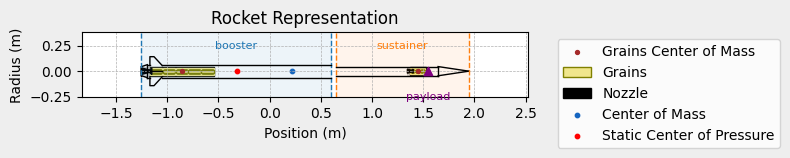

In [10]:
%matplotlib inline
from copy import deepcopy

# Booster: fins + tail only, no nose cone of its own - real boosters
# don't have one, only the sustainer sitting on top does. Since it has
# no nose cone, only its aft (tail-ward) edge is trustworthy from
# surfaces alone; length=1.85 is the booster's own true total length,
# extending forward from that aft edge (not from the stage's own
# coordinate origin - calisto's own motor sits at z=-1.255, nowhere
# near 0, so anchoring at the origin would place the derived extent
# somewhere the booster's fins/tail don't even span).
draw_booster_rocket = deepcopy(calisto)
draw_booster_rocket.add_trapezoidal_fins(
    n=3,
    root_chord=0.120,
    tip_chord=0.040,
    span=0.100,
    position=-1.04956,
)
draw_booster_rocket.add_tail(
    top_radius=0.0635, bottom_radius=0.0435, length=0.060, position=-1.194656
)
draw_booster = Stage(name="booster", rocket=draw_booster_rocket, length=1.85)

# Sustainer: nose cone only, no fins/tail of its own. Its trustworthy
# edge is the opposite one - the nose tip - so length=1.3 (its own true
# total length) extends aft from the tip instead. It also gets its own
# motor (a real two-stage rocket has two): flight_rocket() can only
# attach ONE motor to the composed stack Rocket used for the picture (a
# Rocket carries a single active motor), so draw() draws every other
# stage's own motor separately, at its own stacked position - this is
# what to look for below: both the booster's AND the sustainer's own
# grains/nozzle should be visible, not just the bottom stage's. Sized
# to actually fit the sustainer's own 0.045 m radius and ~1 m of body
# (reusing calisto's own much larger motor here would visually bulge
# out of a rocket a third its size).
sustainer_motor = SolidMotor(
    thrust_source=800,
    dry_mass=0.3,
    dry_inertia=(0.01, 0.01, 0.001),
    nozzle_radius=0.02,
    grain_number=3,
    grain_density=1800,
    grain_outer_radius=0.03,
    grain_initial_inner_radius=0.01,
    grain_initial_height=0.05,
    grain_separation=0.002,
    grains_center_of_mass_position=0.1,
    center_of_dry_mass_position=0.08,
    nozzle_position=0,
    burn_time=1.5,
    throat_radius=0.008,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)
draw_sustainer_rocket = Rocket(
    radius=0.045,
    mass=3.0,
    inertia=(0.2, 0.2, 0.005),
    power_off_drag=0.5,
    power_on_drag=0.5,
    center_of_mass_without_motor=1.0,
)
draw_sustainer_rocket.add_nose(length=0.3, kind="conical", position=0.5)
draw_sustainer_rocket.add_motor(sustainer_motor, position=-0.1)
draw_sustainer = Stage(name="sustainer", rocket=draw_sustainer_rocket, length=1.3)

# interstage_lengths=[0.05]: a 5 cm gap between the booster's own true
# top and the sustainer's own true bottom - MultiStageRocket derives
# the sustainer's actual stacked position from this, rather than
# requiring it pre-positioned in a shared frame.
draw_vehicle = MultiStageRocket(
    stages=[draw_booster, draw_sustainer], interstage_lengths=[0.05]
)
draw_vehicle.add_deployable(
    name="payload",
    mass=0.5,
    inertia=(0.01, 0.01, 0.001),
    position=0.1,
    stage=draw_sustainer,
    radius=0.02,
)

draw_vehicle.draw()

## `MultiStageRocket.draw()` generalizes to N stages

Everything above - per-stage motor rendering, filling in a stage's undrawn body gap, and not letting a tube connect straight across a stage boundary - is written generically over `self.stages`, not hardcoded to two. A three-stage vehicle below proves it, including a middle stage with **no aerodynamic surfaces of its own at all** (a bare interstage adapter) - `length=...` alone is enough to place and shade it correctly.

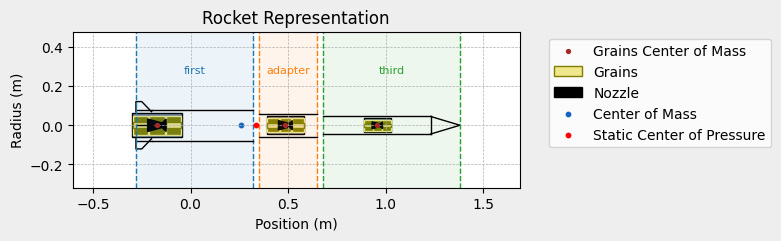

In [11]:
def _demo_motor(radius, thrust, grains_center_of_mass_position):
    # Sized relative to the stage's own body radius (not reused from a
    # bigger/smaller stage) - the two-stage demo above hit exactly this
    # mistake once already (reusing calisto's own much bigger motor for
    # a small sustainer bulged visibly out of its body).
    return SolidMotor(
        thrust_source=thrust,
        dry_mass=0.3,
        dry_inertia=(0.01, 0.01, 0.001),
        nozzle_radius=radius * 0.4,
        grain_number=3,
        grain_density=1800,
        grain_outer_radius=radius * 0.6,
        grain_initial_inner_radius=radius * 0.2,
        grain_initial_height=radius,
        grain_separation=radius * 0.05,
        grains_center_of_mass_position=grains_center_of_mass_position,
        center_of_dry_mass_position=grains_center_of_mass_position * 0.8,
        nozzle_position=0,
        burn_time=1.5,
        throat_radius=radius * 0.15,
        coordinate_system_orientation="nozzle_to_combustion_chamber",
    )


def _draw_demo_stage(name, radius, mass, length, motor_position, nose=False, aft=False):
    rocket = Rocket(
        radius=radius,
        mass=mass,
        inertia=(0.1, 0.1, 0.002),
        power_off_drag=0.5,
        power_on_drag=0.5,
        center_of_mass_without_motor=0.0,
    )
    # Every real stage carries its own motor - including "adapter"
    # below, which has no aerodynamic surfaces of its own but is still
    # an active, motorized stage, not just structural.
    rocket.add_motor(
        _demo_motor(radius, thrust=500, grains_center_of_mass_position=radius * 0.6),
        position=motor_position,
    )
    if aft:
        rocket.add_trapezoidal_fins(
            n=3, root_chord=0.08, tip_chord=0.03, span=0.06, position=-0.2
        )
    if nose:
        rocket.add_nose(length=0.15, kind="conical", position=0.2)
    return Stage(name=name, rocket=rocket, length=length)


# Bottom: fins only (no nose - the next stage provides one). Motor
# sits near the aft, close to the fins.
# Middle: no surfaces at all - a bare interstage adapter, placed and
# shaded purely from its own length=... override - but still carries
# its own motor, positioned within its own declared body.
# Top: nose only (no fins/tail - the stage below provides those).
# Motor sits aft of the nose base, within the declared body.
n_stage_vehicle = MultiStageRocket(
    stages=[
        _draw_demo_stage("first", 0.08, 4.0, 0.6, motor_position=-0.22, aft=True),
        _draw_demo_stage("adapter", 0.06, 1.0, 0.3, motor_position=0.1),
        _draw_demo_stage("third", 0.045, 1.5, 0.7, motor_position=-0.25, nose=True),
    ],
    interstage_lengths=[0.03, 0.03],
)

n_stage_vehicle.draw()

## `Mission`: the degenerate single-flight case

`Mission` is the orchestrator that will eventually walk a vehicle's separation/ejection events and run one `Flight` per configuration with state handoff between them. Right now only the simplest case is implemented: a single-stage vehicle with no deployables degenerates to a thin wrapper around one `Flight` - confirming the invariant stated in `mission_multistage_design.md`. Anything else raises `NotImplementedError` for now.

A plain `Rocket` is sugar for a single-stage `MultiStageRocket` with nothing separable, so `Mission` accepts either directly.

In [12]:
from rocketpy import Environment
from rocketpy.simulation.mission import Mission

mission = Mission(
    vehicle=calisto,
    environment=Environment(),
    rail_length=5.2,
    inclination=85,
    heading=0,
)

print(f"bodies flown: {list(mission.flights.keys())}")
print(f"flights for 'stage_1': {mission.flights['stage_1']}")
print("\ntimeline:")
for time, event in mission.timeline:
    print(f"  t={time:8.3f}s  {event}")

bodies flown: ['stage_1']
flights for 'stage_1': [<Flight(rocket= <rocketpy.rocket.rocket.Rocket object at 0x115f092b0>, environment= <rocketpy.environment.environment.Environment object at 0x115f09940>, rail_length= 5.2, inclination= 85, heading = 0,name= stage_1)>]

timeline:
  t=   0.000s  ignition:stage_1
  t=   0.000s  liftoff
  t=   0.415s  rail_departure
  t=   3.900s  burnout:stage_1
  t=  25.091s  apogee:stage_1
  t=  48.437s  impact:stage_1


/Users/dubeyishan371/Desktop/Rocketpy-main/RocketPy/rocketpy/simulation/flight.py:628: UnstableRocketWarning: The rocket has a negative static margin (-1.74 cal) at motor ignition (t=0), indicating an aerodynamically unstable configuration. Check the placement of fins and nose cone relative to the center of mass.
  self.rocket.warn_if_unstable()


## `Mission`: a real two-stage flight

With two stages, `Mission` runs three `Flight`s: the full stack (booster firing), then the spent booster falling away on its own, and the sustainer continuing on its own. Separation and ignition timing are deterministic - computed ahead of time from `booster.burn_out_time + booster.separation` and `sustainer.ignition_delay` - there's no generic mid-flight event solver in RocketPy today, only `Flight`'s `max_time` and `terminate_on_apogee`.

The handoff between stack and children follows `mission_multistage_design.md`'s `_handoff_state`: the parent's ending position/velocity is transformed by the body-frame offset between the parent and child center-of-dry-mass, rotated into the inertial frame, plus (for the child) its momentum-conserving share of `separation_delta_v`. The sustainer's own motor is additionally re-anchored in time so it ignites at its actual mission time, not its own local t=0 (`_shift_motor_ignition`).

In [13]:
from rocketpy.motors.point_mass_motor import PointMassMotor

ts_booster_rocket = Rocket(
    radius=0.1,
    mass=10.0,
    inertia=(1.0, 1.0, 0.01),
    power_off_drag=0.5,
    power_on_drag=0.6,
    center_of_mass_without_motor=0.0,
)
ts_booster_rocket.add_motor(
    PointMassMotor(
        thrust_source=400, dry_mass=1.0, propellant_initial_mass=2.0, burn_time=1.0
    ),
    position=0.0,
)
# separation: burns out at t=1.0s, jettisoned 0.5s later
ts_booster = Stage(name="booster", rocket=ts_booster_rocket, separation=0.5)

ts_sustainer_rocket = Rocket(
    radius=0.08,
    mass=5.0,
    inertia=(0.5, 0.5, 0.005),
    power_off_drag=0.3,
    power_on_drag=0.4,
    center_of_mass_without_motor=2.0,
)
ts_sustainer_rocket.add_motor(
    PointMassMotor(
        thrust_source=200, dry_mass=0.5, propellant_initial_mass=1.0, burn_time=1.0
    ),
    position=2.0,
)
# ignites immediately on separation
ts_sustainer = Stage(name="sustainer", rocket=ts_sustainer_rocket, ignition_delay=0.0)

two_stage_vehicle = MultiStageRocket(stages=[ts_booster, ts_sustainer])

In [14]:
two_stage_mission = Mission(
    vehicle=two_stage_vehicle,
    environment=Environment(),
    rail_length=1.0,
    inclination=84,
    heading=30,  # off dead-vertical, for a real 3D trajectory
    max_time=30,
)

print(f"bodies flown: {list(two_stage_mission.flights.keys())}")
print(
    "'booster' flights (stack, then booster alone): "
    f"{len(two_stage_mission.flights['booster'])}"
)
print(
    "'sustainer' flights (stack, then sustainer alone): "
    f"{len(two_stage_mission.flights['sustainer'])}"
)
print("\ntimeline:")
for time, event in two_stage_mission.timeline:
    print(f"  t={time:8.3f}s  {event}")

/Users/dubeyishan371/Desktop/Rocketpy-main/RocketPy/rocketpy/simulation/flight.py:1621: UserWarning: A point-mass model was detected. Simulation mode should be '3 DOF'.
  warnings.warn(
/Users/dubeyishan371/Desktop/Rocketpy-main/RocketPy/rocketpy/motors/motor.py:1165: UserWarning: Reference pressure not set. Returning thrust instead.
  warnings.warn(
Only one motor per rocket is currently supported. Overwriting previous motor.


bodies flown: ['booster', 'sustainer']
'booster' flights (stack, then booster alone): 2
'sustainer' flights (stack, then sustainer alone): 2

timeline:
  t=   0.000s  ignition:booster
  t=   0.000s  liftoff
  t=   0.425s  rail_departure
  t=   1.000s  burnout:booster
  t=   1.500s  separation:booster
  t=   1.500s  ignition:sustainer
  t=   2.196s  apogee:booster
  t=   2.500s  burnout:sustainer
  t=   3.759s  impact:booster
  t=   5.496s  apogee:sustainer
  t=   9.351s  impact:sustainer


## `Mission`: a deployable ejecting at apogee

A single-stage vehicle with exactly one deployable whose `ejection` is the string `"apogee"` runs a different three-`Flight` sequence: the carrier stage flying with the deployable aboard (using the existing `terminate_on_apogee` flag on `Flight` - no new event machinery needed), then two children from the apogee state onward - the carrier stage continuing without the deployable's mass, and the deployable flying its own `free_rocket`.

Same `_handoff_state` transform as the two-stage case, and the same momentum-conserving delta_v split, just generalized: any two children of a split share `separation_delta_v` in inverse proportion to their post-split masses.

`ejection` other than `"apogee"`, and deployables defined via `add_surface()` instead of `free_rocket`, aren't supported yet.

In [15]:
carrier_rocket = Rocket(
    radius=0.1,
    mass=10.0,
    inertia=(1.0, 1.0, 0.01),
    power_off_drag=0.5,
    power_on_drag=0.6,
    center_of_mass_without_motor=0.0,
)
carrier_rocket.add_motor(
    PointMassMotor(
        thrust_source=400, dry_mass=1.0, propellant_initial_mass=2.0, burn_time=1.0
    ),
    position=0.0,
)
carrier = Stage(name="carrier", rocket=carrier_rocket)

payload_rocket = Rocket(
    radius=0.02,
    mass=1.0,
    inertia=(0.001, 0.001, 0.0001),
    power_off_drag=0.5,
    power_on_drag=0.5,
    center_of_mass_without_motor=0.0,
)

deployable_vehicle = MultiStageRocket(stages=[carrier])
deployable_vehicle.add_deployable(
    name="payload",
    mass=1.0,
    inertia=(0.001, 0.001, 0.0001),
    position=1.0,
    free_rocket=payload_rocket,
    ejection="apogee",
)

In [16]:
deployable_mission = Mission(
    vehicle=deployable_vehicle,
    environment=Environment(),
    rail_length=1.0,
    inclination=84,
    heading=30,  # off dead-vertical, for a real 3D trajectory
    max_time=20,
)

print(f"bodies flown: {list(deployable_mission.flights.keys())}")
print(
    "'carrier' flights (with payload, then alone): "
    f"{len(deployable_mission.flights['carrier'])}"
)
print(
    "'payload' flights (with carrier, then alone): "
    f"{len(deployable_mission.flights['payload'])}"
)
print("\ntimeline:")
for time, event in deployable_mission.timeline:
    print(f"  t={time:8.3f}s  {event}")

bodies flown: ['carrier', 'payload']
'carrier' flights (with payload, then alone): 2
'payload' flights (with carrier, then alone): 2

timeline:
  t=   0.000s  ignition:carrier
  t=   0.000s  liftoff
  t=   0.322s  rail_departure
  t=   1.000s  burnout:carrier
  t=   3.100s  apogee:payload
  t=   3.100s  apogee:carrier
  t=   3.100s  apogee:carrier+payload
  t=   3.100s  ejection:payload
  t=   5.632s  impact:carrier
  t=   5.639s  impact:payload


## Visualizing trajectories: `Mission.trajectories_3d()` / `Mission.positions()`

`Mission` wraps `CompareFlights(mission.all_flights)` directly for the common cases - a plain 3D trajectory plot and per-axis position-vs-time plots - so a caller doesn't need to know `CompareFlights` exists just to see a mission's trajectory, the same way a single `Flight` exposes its own `trajectory_3d()`. `all_flights` (every `Flight` a `Mission` ran, in execution order, each appearing once even when several bodies shared it - the full stack's flight is one object, referenced by both `flights["booster"]` and `flights["sustainer"]`) is still there directly for any other `CompareFlights` plot these two don't wrap, e.g. `CompareFlights(mission.all_flights).velocities()`.

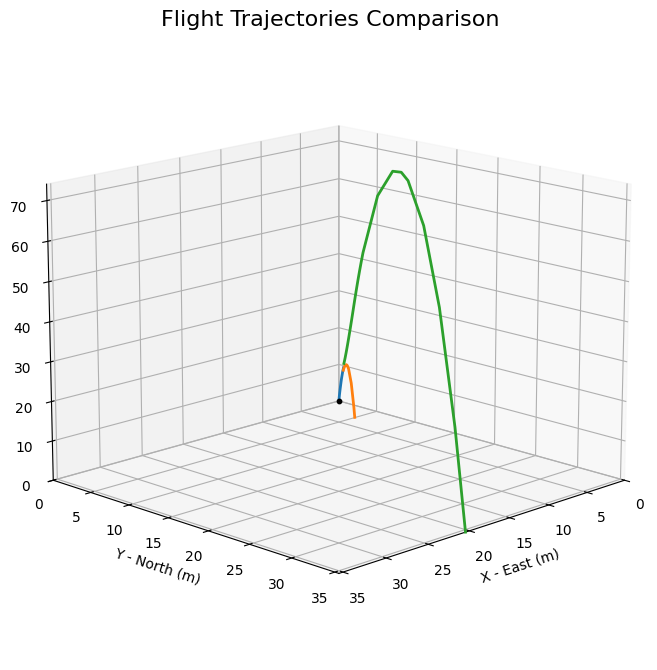

In [17]:
two_stage_mission.trajectories_3d()

/Users/dubeyishan371/Desktop/Rocketpy-main/RocketPy/rocketpy/plots/plot_helpers.py:65: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


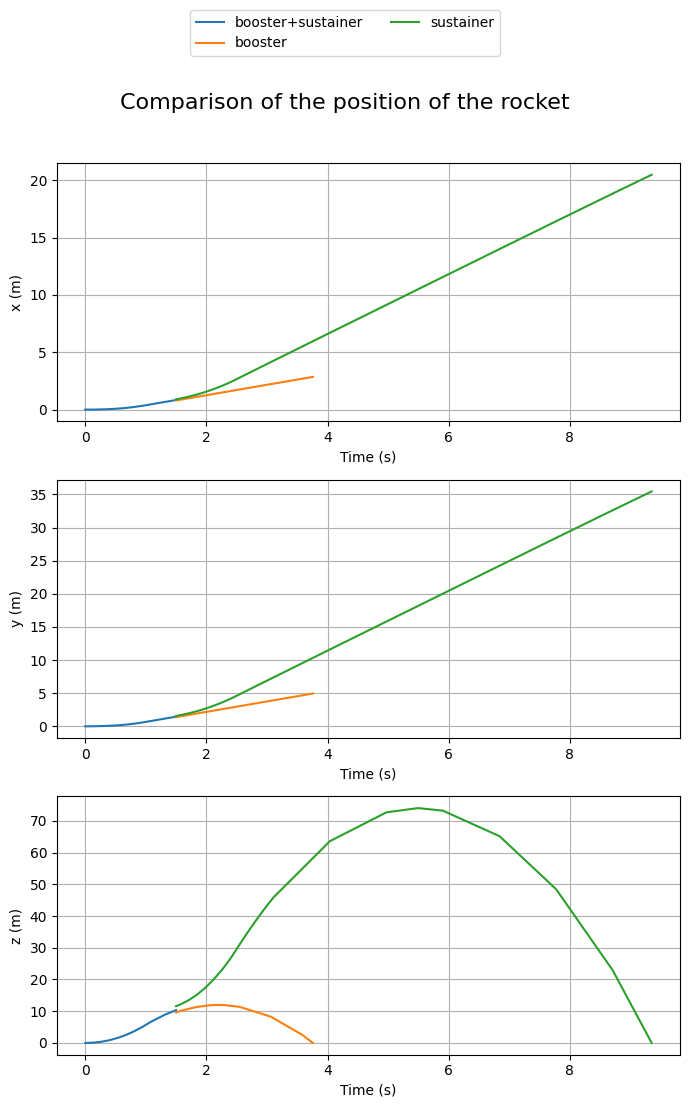

In [18]:
two_stage_mission.positions()

Same thing for the deployable mission - the carrier and the payload separate at apogee and fall along very similar paths, which is exactly what's expected given they split with zero `separation_delta_v`.

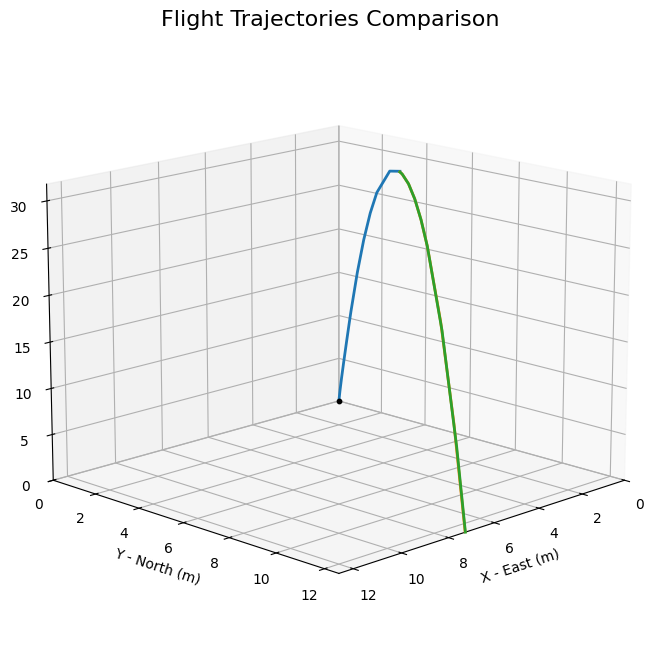

In [19]:
deployable_mission.trajectories_3d()

## Visualizing events: `Mission.plot_timeline()`

`trajectories_3d()`/`positions()` above show *where* each body went; `plot_timeline()` shows *when* things happened - altitude vs time for every flight, with every timeline event (ignition, **burnout**, separation, ejection, **apogee**, impact, ...) marked and labeled at its own time. `burnout` and `apogee` are new timeline entries as of this section - previously `mission.timeline` only recorded ignition/liftoff/separation/ejection/impact.

It reads only `mission.timeline`'s `(time, name)` tuples - nothing about *how* those got there. That matters beyond this notebook: if `mission.timeline` is ever built from real `Event` objects instead of Mission's own deterministic bookkeeping (once upstream PR #968, "Events Class and Flight Rework", lands - see the "Remaining gaps" section below), this plot keeps working completely unchanged.

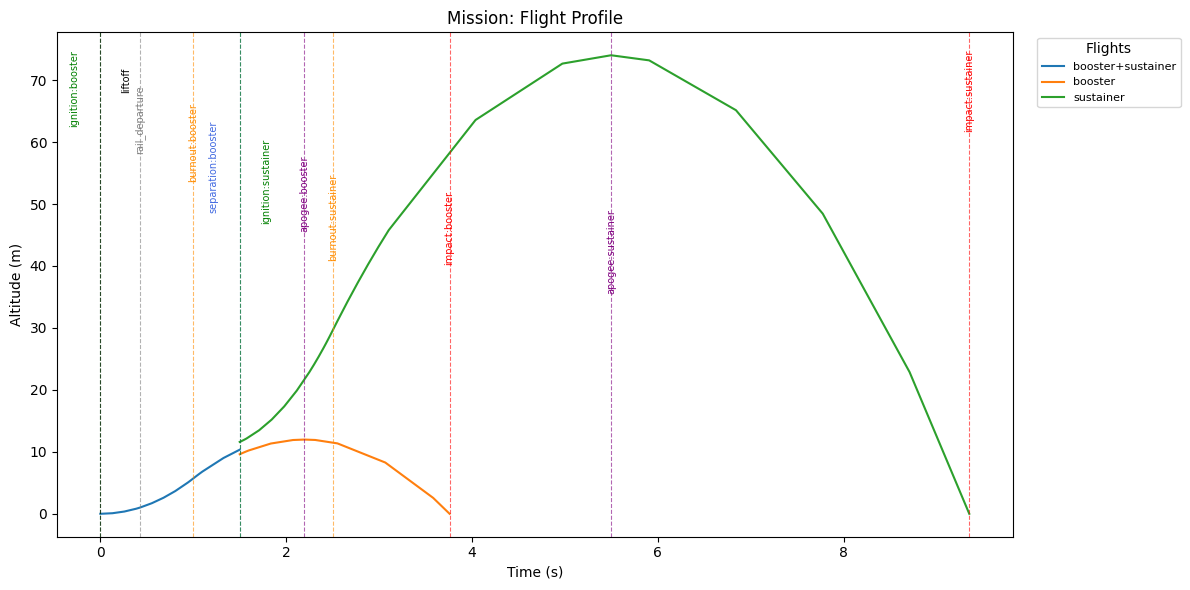

In [20]:
two_stage_mission.plot_timeline()

Same plot for the deployable-ejecting mission - notice `apogee:carrier+payload` and `ejection:payload` land at (nearly) the same time, since ejection happens exactly at apogee.

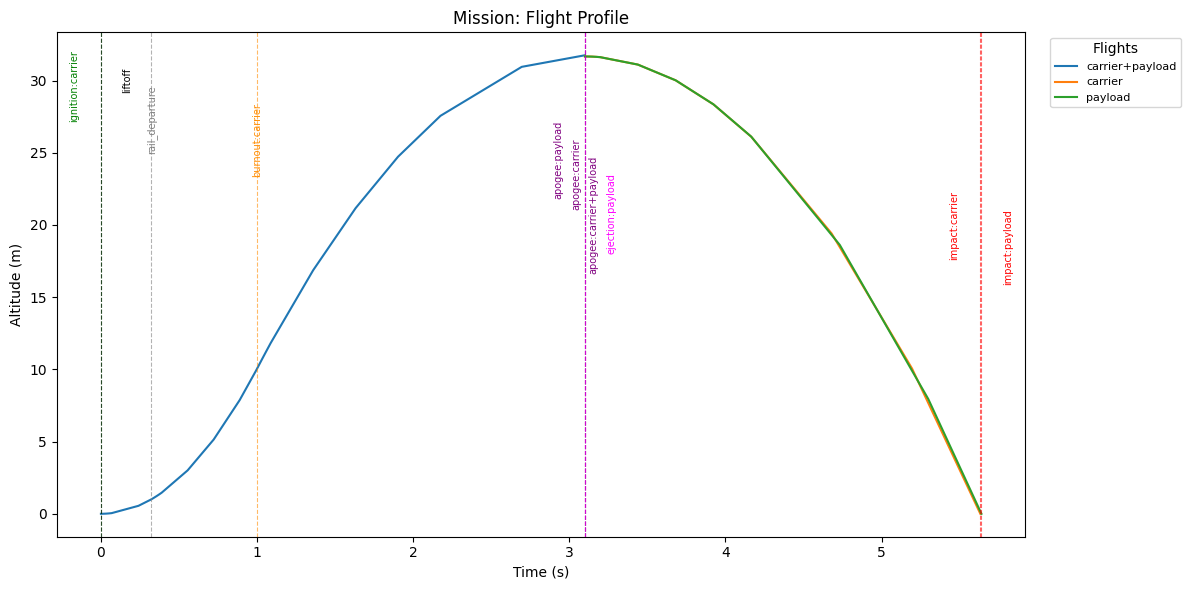

In [21]:
deployable_mission.plot_timeline()

## Visualizing events in 3D: `Mission.plot_trajectory_events()`

Same idea as `plot_timeline()`, but on the actual 3D flight path instead of altitude vs time - every event is a colored, distinctly-shaped **point** at its own position (not a line, which has no natural per-instant meaning in 3D). Each event type gets its own marker shape and color (a triangle for liftoff, a diamond for separation, a star for apogee, an X for impact, ...), the way mission-control telemetry displays mark up a trajectory.

Each event's exact position comes from `flight.x(t)`, `flight.y(t)`, `flight.z(t)` - the same post-processed, continuously-interpolated Functions `Flight` already exposes - evaluated on whichever flight's own time span covers that event, found via `Mission._flight_covering_time()`.

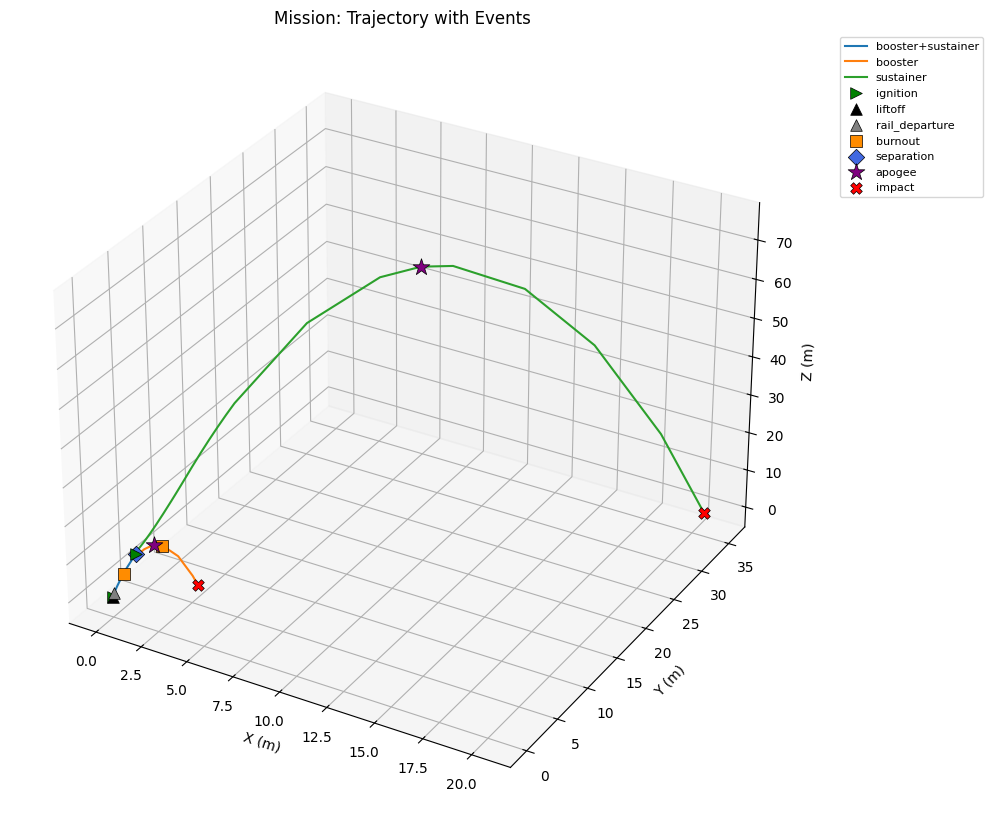

In [22]:
two_stage_mission.plot_trajectory_events()

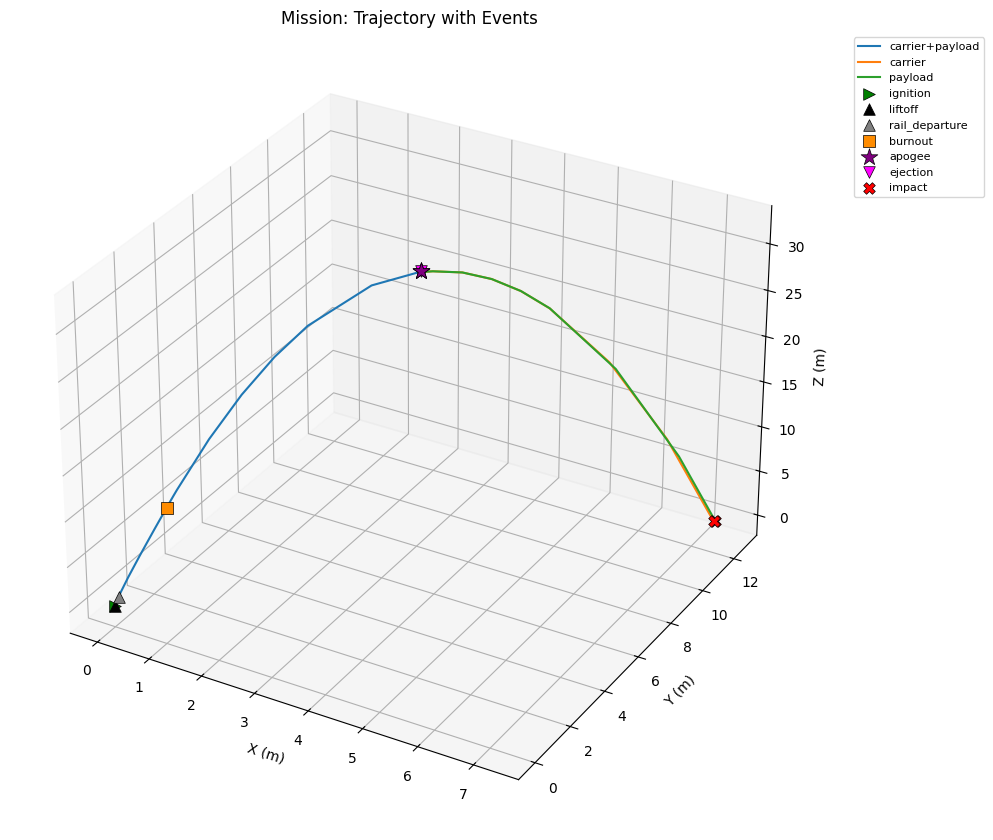

In [23]:
deployable_mission.plot_trajectory_events()

## `Mission`: more than two stages

The two-stage walk above is one instance of a general recursive walk: at every configuration, `Mission` composes the active stages and carried deployables into one `Rocket`, runs it to whichever comes first - the bottom stage's own separation, or a carried deployable's apogee ejection - then recurses into whatever results (the departing body falling away alone, and the remaining configuration continuing). A three-stage vehicle is the same walk one level deeper: after the booster separates, the remaining sustainer+kick stack continues exactly like a fresh two-stage vehicle, right down to re-anchoring the sustainer's motor to ignite at its real mission time - and when *that* separates in turn, the kick stage's own motor gets the same treatment.

In [24]:
gs_booster_rocket = Rocket(
    radius=0.1,
    mass=10.0,
    inertia=(1.0, 1.0, 0.01),
    power_off_drag=0.5,
    power_on_drag=0.6,
    center_of_mass_without_motor=0.0,
)
gs_booster_rocket.add_motor(
    PointMassMotor(
        thrust_source=400, dry_mass=1.0, propellant_initial_mass=2.0, burn_time=1.0
    ),
    position=0.0,
)
gs_booster = Stage(name="booster", rocket=gs_booster_rocket, separation=0.5)

gs_sustainer_rocket = Rocket(
    radius=0.08,
    mass=5.0,
    inertia=(0.5, 0.5, 0.005),
    power_off_drag=0.3,
    power_on_drag=0.4,
    center_of_mass_without_motor=2.0,
)
gs_sustainer_rocket.add_motor(
    PointMassMotor(
        thrust_source=200, dry_mass=0.5, propellant_initial_mass=1.0, burn_time=1.0
    ),
    position=2.0,
)
gs_sustainer = Stage(name="sustainer", rocket=gs_sustainer_rocket, separation=0.5)

gs_kick_rocket = Rocket(
    radius=0.04,
    mass=2.0,
    inertia=(0.1, 0.1, 0.001),
    power_off_drag=0.2,
    power_on_drag=0.3,
    center_of_mass_without_motor=3.0,
)
gs_kick_rocket.add_motor(
    PointMassMotor(
        thrust_source=100, dry_mass=0.2, propellant_initial_mass=0.5, burn_time=1.0
    ),
    position=3.0,
)
gs_kick = Stage(name="kick", rocket=gs_kick_rocket)

three_stage_vehicle = MultiStageRocket(stages=[gs_booster, gs_sustainer, gs_kick])

three_stage_mission = Mission(
    vehicle=three_stage_vehicle,
    environment=Environment(),
    rail_length=1.0,
    inclination=84,
    heading=30,
    max_time=30,
)

print(f"bodies flown: {list(three_stage_mission.flights.keys())}")
for name in ("booster", "sustainer", "kick"):
    print(f"'{name}' flights: {len(three_stage_mission.flights[name])}")
print("\ntimeline:")
for time, event in three_stage_mission.timeline:
    print(f"  t={time:8.3f}s  {event}")

Only one motor per rocket is currently supported. Overwriting previous motor.


Only one motor per rocket is currently supported. Overwriting previous motor.


bodies flown: ['booster', 'sustainer', 'kick']
'booster' flights: 2
'sustainer' flights: 3
'kick' flights: 3

timeline:
  t=   0.000s  ignition:booster
  t=   0.000s  liftoff
  t=   0.485s  rail_departure
  t=   1.000s  burnout:booster
  t=   1.500s  separation:booster
  t=   1.500s  ignition:sustainer
  t=   1.922s  apogee:booster
  t=   2.500s  burnout:sustainer
  t=   3.000s  separation:sustainer
  t=   3.000s  ignition:kick
  t=   3.159s  impact:booster
  t=   4.000s  burnout:kick
  t=   4.241s  apogee:sustainer
  t=   6.865s  impact:sustainer
  t=   8.298s  apogee:kick
  t=  13.711s  impact:kick


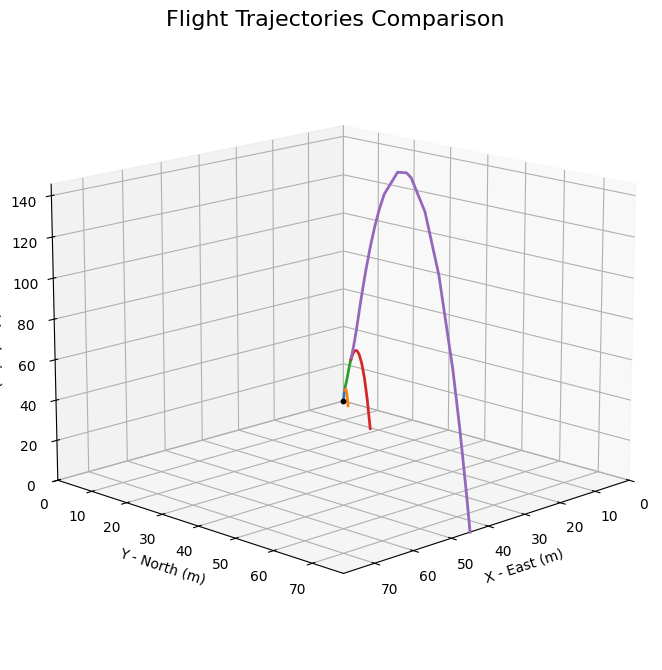

In [25]:
three_stage_mission.trajectories_3d()

## `Mission`: a deployable combined with a multi-stage vehicle

The other half of Gap 1: a deployable doesn't have to ride a single-stage vehicle. Here the payload rides the *sustainer* of a two-stage vehicle - still aboard through the booster's own separation (it isn't `sustainer.stage`, it's carried by the whole remaining stack), only ejecting later at the sustainer's own apogee. The walk applies its usual priority: a pending stage separation always resolves before any carried deployable's apogee ejection, which is why the booster falls away first here even though both events are, in principle, "whatever happens next" candidates.

In [26]:
dm_booster_rocket = Rocket(
    radius=0.1,
    mass=10.0,
    inertia=(1.0, 1.0, 0.01),
    power_off_drag=0.5,
    power_on_drag=0.6,
    center_of_mass_without_motor=0.0,
)
dm_booster_rocket.add_motor(
    PointMassMotor(
        thrust_source=400, dry_mass=1.0, propellant_initial_mass=2.0, burn_time=1.0
    ),
    position=0.0,
)
dm_booster = Stage(name="booster", rocket=dm_booster_rocket, separation=0.5)

dm_sustainer_rocket = Rocket(
    radius=0.08,
    mass=5.0,
    inertia=(0.5, 0.5, 0.005),
    power_off_drag=0.3,
    power_on_drag=0.4,
    center_of_mass_without_motor=2.0,
)
dm_sustainer_rocket.add_motor(
    PointMassMotor(
        thrust_source=200, dry_mass=0.5, propellant_initial_mass=1.0, burn_time=1.0
    ),
    position=2.0,
)
dm_sustainer = Stage(name="sustainer", rocket=dm_sustainer_rocket)

dm_vehicle = MultiStageRocket(stages=[dm_booster, dm_sustainer])

dm_payload_rocket = Rocket(
    radius=0.02,
    mass=0.2,
    inertia=(0.001, 0.001, 0.0001),
    power_off_drag=0.5,
    power_on_drag=0.5,
    center_of_mass_without_motor=0.0,
)
dm_vehicle.add_deployable(
    name="payload",
    mass=0.2,
    inertia=(0.001, 0.001, 0.0001),
    position=1.5,
    stage=dm_sustainer,
    free_rocket=dm_payload_rocket,
    ejection="apogee",
)

deployable_multistage_mission = Mission(
    vehicle=dm_vehicle,
    environment=Environment(),
    rail_length=1.0,
    inclination=84,
    heading=30,
    max_time=20,
)

print(f"bodies flown: {list(deployable_multistage_mission.flights.keys())}")
for name in ("booster", "sustainer", "payload"):
    print(f"'{name}' flights: {len(deployable_multistage_mission.flights[name])}")
print("\ntimeline:")
for time, event in deployable_multistage_mission.timeline:
    print(f"  t={time:8.3f}s  {event}")

Only one motor per rocket is currently supported. Overwriting previous motor.


bodies flown: ['booster', 'sustainer', 'payload']
'booster' flights: 2
'sustainer' flights: 3
'payload' flights: 3

timeline:
  t=   0.000s  ignition:booster
  t=   0.000s  liftoff
  t=   0.429s  rail_departure
  t=   1.000s  burnout:booster
  t=   1.500s  separation:booster
  t=   1.500s  ignition:sustainer
  t=   2.174s  apogee:booster
  t=   2.500s  burnout:sustainer
  t=   3.711s  impact:booster
  t=   5.377s  ejection:payload
  t=   5.377s  apogee:payload
  t=   5.377s  apogee:sustainer
  t=   9.005s  impact:payload
  t=   9.115s  impact:sustainer


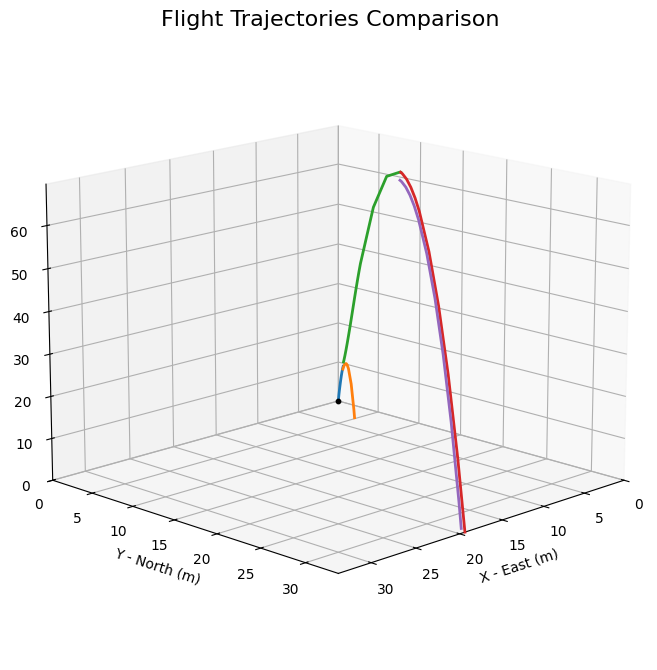

In [27]:
deployable_multistage_mission.trajectories_3d()

## Quick reference: build sequence

Three flowcharts tying together every function used above, in the order you actually call them. They only name the functions *you* write - not what `Rocket`/`Mission` do internally with them.

### 1. Building a two-stage rocket

```text
for EACH of the 2 stages, bottom -> top:

    build a Rocket()                    <- this stage's own
         |                                  structure + aero
         v
    build a Motor                       <- SolidMotor / HybridMotor /
         |                                  LiquidMotor / GenericMotor /
         v                                  PointMassMotor
    rocket.add_motor(motor, position=...)
         |
         v
    Stage(name=..., rocket=rocket, ...)
         bottom stage : separation=<seconds after ITS burnout>
         top stage    : ignition_delay=<seconds after bottom separates>

----------------------------------------------------------------
    MultiStageRocket(stages=[bottom_stage, top_stage])
----------------------------------------------------------------
         |
         v
    Mission(vehicle=..., environment=Environment(),
            rail_length=..., inclination=..., heading=...,
            max_time=...)
         (the whole multi-flight simulation runs right here,
          inside the constructor - nothing left to call to
          'start' it)
         |
         v
    read results:      mission.flights / mission.timeline / mission.all_flights
    visualize:          mission.trajectories_3d()
                         mission.positions()
                         mission.plot_timeline()
                         mission.plot_trajectory_events()
```


### 2. Adding more stages (the N-stage case)

Same loop as above, just don't stop at 2 - every extra stage is one more pass through the same four calls, then one more entry in the `stages=[...]` list, bottom to top:

```text
stages = []
for each physical stage, bottom -> top:

    build a Rocket()
         |
         v
    build a Motor
         |
         v
    rocket.add_motor(motor, position=...)
         |
         v
    stages.append(
        Stage(
            name=..., rocket=rocket,
            separation=...,      # set on every stage that will later let
                                 # go of whatever is stacked above it;
                                 # leave unset on the top stage
            ignition_delay=...,  # delay after the stage BELOW separates;
                                 # unset (0) on the bottom stage
            length=...,          # only if this stage has no/ambiguous
        )                        # aero surfaces of its own (e.g. a bare
    )                            # interstage adapter) AND you're using
                                 # interstage_lengths below

----------------------------------------------------------------
    MultiStageRocket(
        stages=stages,
        interstage_lengths=[gap_1_2, gap_2_3, ...],  # optional: N-1 gaps,
    )                             # auto-stacks each stage on the one below
                                  # it via its own aero surfaces. Omit to
                                  # keep every stage's Rocket pre-positioned
                                  # in one shared coordinate frame, as before.
----------------------------------------------------------------
         |
         v
    Mission(vehicle=..., environment=..., rail_length=..., inclination=...,
            heading=..., max_time=...)
         |
         v
    same mission.flights / mission.timeline / plot_timeline() / ...
    as the two-stage case - nothing about reading results changes with N.
```

`Stage.ignition` (an event-triggered ignition, as opposed to a plain delay) and `Stage.separation`/`Deployable.ejection` triggered on anything other than a fixed delay or `"apogee"` aren't implemented yet - see "Remaining gaps" below.

### 3. Adding a deployable

Starts from an already-built `MultiStageRocket` (one stage or many, built exactly as above):

```text
MultiStageRocket already built (from flowchart 1 or 2)
         |
         v
    what is the deployable?
         |
         +---------------------------+
         v                           v
    non-powered payload        free-flying payload with its own
    (fairing half, nose         motor / continued powered flight
     cap, inert probe, ...)     after ejection
         |                           |
         v                           v
    build a Rocket()            build a Rocket()
    (no add_motor call)         rocket.add_motor(motor, position=...)
         |                           |
         +-------------+-------------+
                       v
         that Rocket becomes free_rocket= below
                       |
                       v
    vehicle.add_deployable(
        name=..., mass=..., inertia=..., position=...,
        stage=...,           # which stage carries it; default = top stage
        free_rocket=...,     # the Rocket built above
        ejection="apogee",   # only trigger Mission supports today
    )
----------------------------------------------------------------
         |
         v
    Mission(vehicle=vehicle, environment=..., rail_length=...,
            inclination=..., heading=..., max_time=...)
         |
         v
    same mission.flights / mission.timeline / plot_timeline() / ...
    - the deployable shows up as its own named body, same as a stage.
```

`Deployable.add_surface()` (building the free-flight aero from primitive surfaces instead of a whole pre-built `free_rocket`) exists on `Deployable` but `Mission` doesn't support it yet - `free_rocket` is required for now. See "Remaining gaps" below.

## Remaining gaps

Of the three gaps this notebook originally tracked ("More than two stages, or a deployable combined with a multi-stage vehicle", "Deriving stack positions from `interstage_lengths`", and "Event-triggered separation/ignition/ejection beyond deterministic delays and `apogee`") - the first two are **done**, verified above and via two randomized fuzz sweeps (~1500 configs, then 600 more; 599/600 of the second batch completed cleanly). Only the third remains, still blocked on an upstream `Flight` change (`RocketPy-Team/RocketPy#968`, not yet merged).

**Still open, in priority order:**

1. **Event-triggered separation/ignition/ejection** beyond deterministic delays and `"apogee"` - no generic mid-flight trigger/event solver exists in `Flight` today. Blocked on upstream PR #968 ("Events Class and Flight Rework").
2. **Simultaneous multi-deployable ejection** - `Mission` raises `NotImplementedError` when more than one deployable carried by the same configuration would eject at apogee together (e.g. two side-payloads meant to separate at once). The 2-body momentum split would need generalizing to N bodies.
3. **Deployables via `add_surface()` instead of `free_rocket`** - `Deployable.add_surface()` exists and stores surfaces, but `Mission` still requires `free_rocket` and raises `NotImplementedError` otherwise.
4. **Core `Flight` impact-detection robustness** (not a Mission bug - reproduced with a standalone `Flight()` call too, no `Mission` involved) - two confirmed failures in `Flight`'s own root-finding for small/fast-moving/near-apogee bodies (a `ZeroDivisionError` and a `ValueError("Multiple roots found...")`), each hitting about 0.15% of randomized deployable-ejection configs in the fuzz sweeps. Left untouched deliberately - out of scope for the Mission/multistage work this notebook covers.
5. **`draw()` at a specific mission time** - today `draw()` only shows the full, unseparated vehicle; drawing one specific configuration mid-mission (e.g. right after the booster separates) isn't wired up yet, though nothing about the underlying geometry code would need to change to add it.
6. **`StochasticMission`, `to_dict`/`from_dict`** - not built.